## 3. Model Development

In this section, we move from exploratory data analysis to predictive modeling
The goal is to build and evaluate regression models to predict house prices.

Based on the EDA findings, we will:
- Use the log-transformed target variable (`log_price`),
- Slit the dataset into training and testing sets,
- Train a baseline Linear Regression model,
- Evaluate model performance using R², MAE, and RMSE,
- Analyze model coefficients and assess multicollinearity effects.

We will begin with a full feature set and later compare results with a reduce feature set.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/house_data.csv")

df["date"] = pd.to_datetime(df["date"])
df["log_price"] = np.log(df["price"])

### 3.1 Define Target and Features

We define:
- Target variable (y): log-transformed house price (log_price)
- Features (x): numerical predictors excluding price, lo_price, and id.

The log transformation is used to reduce skewnees and stabilize variance.

In [4]:
y = df["log_price"]
x = df.select_dtypes(include=["int64", "float64"]).drop(columns=["price", "log_price", "id"])

### 3.2 Train/Test Split

We split the data into:
- 80% training data
- 20% testing data

The random_state is fixed (42) to unsure reproducibility.

In [5]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### 3.3 Baseline Linear Regression

We train a baseline Linear Regression model using all selected features.

In [6]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 3.4 Evaluation

In [8]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
y_pred = model.predict(x_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2, mae, rmse

(0.770979992283767, 0.1964048571351213, np.float64(0.2554956739785922))

In [9]:
r2_train = r2_score(y_train, model.predict(x_train))
r2_train

0.7701573772668612

### Model Performance (Full Feature Set)

- R² (test): 0.77
- R² (train): 0.77

The model shows similar performance on training and testing data, indicating no significant overfitting.
Aproximately 77% of the variance in log house prices is explained by the model.

In [10]:
pd.DataFrame({"Feature": x.columns, "Coefficient": model.coef_}).sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
14,lat,1.401705e+00
5,waterfront,3.744222e-01
8,grade,1.565359e-01
4,floors,7.500426e-02
1,bathrooms,7.342734e-02
6,view,6.206787e-02
7,condition,6.093629e-02
16,sqft_living15,9.811169e-05
2,sqft_living,9.668479e-05
10,sqft_basement,5.574329e-05


### Feature Importance (Linear Regression Coefficients)

Latitude (lat) has the strongest positive impact on house prices.
Waterfront and grade also significantly increase property value.
Some features such as bedrooms and longitude show negative coefficients, which may indicate multicollinearity effects.

### Predicted vs Actual (TEST SET)

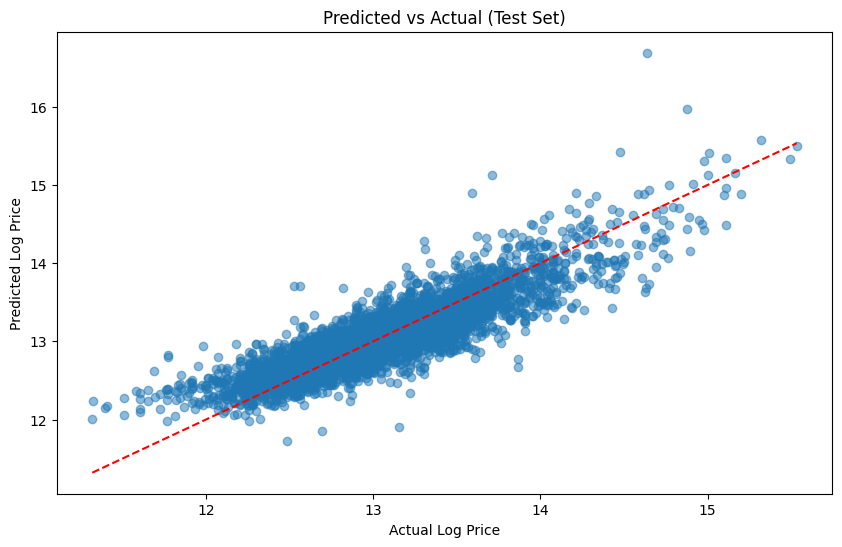

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Predicted vs Actual (Test Set)")
plt.show()

### Residual Plot

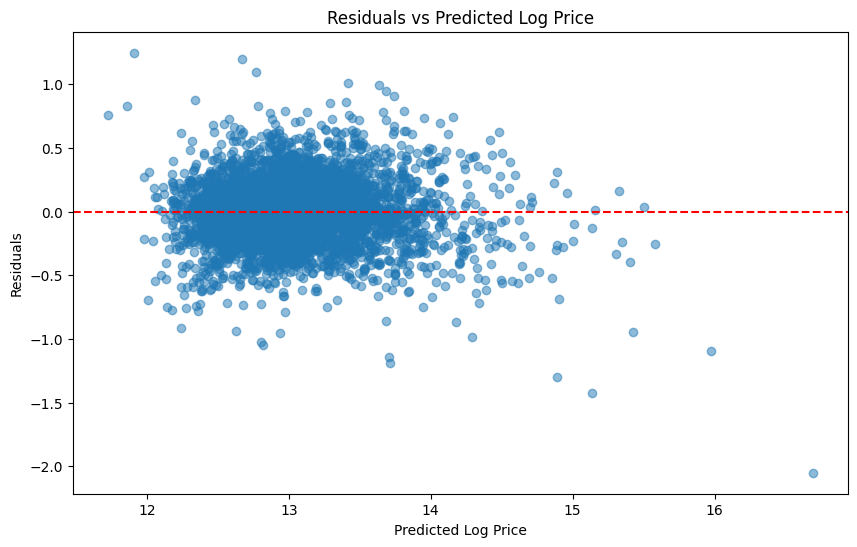

In [21]:
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Log Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Log Price")
plt.show()

### Model Diagnostics (Test Set)

### Predicted vs Actual

Points are reasonably close to the diagonal line, indicating good predictive performance.
There is no clear systematic pattern, suggesting the model does not show strong bias.
Some dispersion is visible for higher prices, which may indicate increased prediction difficulty for more expensive properties.

### Residual 

The residuals are randomly distributed arround zero, indicating that the linearity assumption is reasonably satisfied.
No clear systematic pattern is visible, suggesting that the model does not suffer from strong bias.
A slightly larger dispersion is observed for higher predicted values, which may increased  uncertainty when predicting more expensive properties.

### 3.5 Reduced Model (Without Redundant Features)

In [13]:
x = df.select_dtypes(include=["int64", "float64"]).drop(columns=["price", "log_price", "id", "sqft_above", "sqft_basement", "sqft_living15"])

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
y_pred = model.predict(x_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2, mae, rmse

(0.7652131770674515, 0.19749629965352242, np.float64(0.2586924168054027))

In [16]:
r2_train = r2_score(y_train, model.predict(x_train))
r2_train

0.7646804237367759

In [17]:
pd.DataFrame({"Feature": x.columns, "Coefficient": model.coef_}).sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
12,lat,1.417414e+00
5,waterfront,3.577098e-01
8,grade,1.737919e-01
6,view,7.190284e-02
1,bathrooms,7.021082e-02
4,floors,6.436670e-02
7,condition,5.776900e-02
2,sqft_living,1.792195e-04
10,yr_renovated,3.008894e-05
3,sqft_lot,3.115505e-07


### Reduce Model Comparison

After removing potentially redundant features (sqft_above, sqft_basement, sqft_living15), model performance slightly changed.
This helps assess the impact of multicollinearity.

## Final Summary

- A baseline Linear Regression model was trained using log-transformed house prices.
- The model achieved R² ~ 0,77 on both training and test sets, indicating stable generalization and no significant overfitting.
- Diagnostic plots (Predicted vs Actual and Residuals) show predictions reasonably aligned with the diagonal line and residuals centered arround zero, suggesting that the linearity assumption is largely satisfied.
- Slightly higher dispersion for higher-priced properties indicates increased prediction uncertainty for more expensive homes.
- A reduced feature set (dropping `sqft_above`, `sqft_basement`, `sqft_living15`) produced similar performance, suggesting limited benefit from removing these redundant variables at this stage.
- Future improvements may include  applying regularization techniques (Ridge/Lasso) and hyperparameter tuning (GridSearchCV) to further enhance model robustness and generalization.